In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

In [7]:
df = pd.read_csv("heart_disease_uci.csv")

# Drop ID
df = df.drop("id", axis=1)

# Convert to binary classification
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

# Handle missing values
df = df.fillna(df.median(numeric_only=True))

for col in df.select_dtypes(include="object"):
    df[col] = df[col].fillna(df[col].mode()[0])

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

print("Dataset ready")

Dataset ready


/var/folders/6q/22szj_gx0kv2qm4d1nxgfqh00000gn/T/ipykernel_14029/779626977.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [8]:
df["age_chol"] = df["age"] * df["chol"]
df["bp_chol"] = df["trestbps"] * df["chol"]
df["stress_hr"] = df["oldpeak"] * df["thalch"]

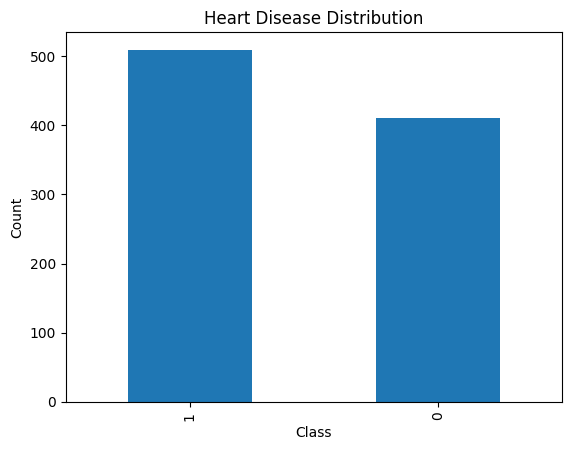

In [9]:
plt.figure()
df["num"].value_counts().plot(kind="bar")
plt.title("Heart Disease Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

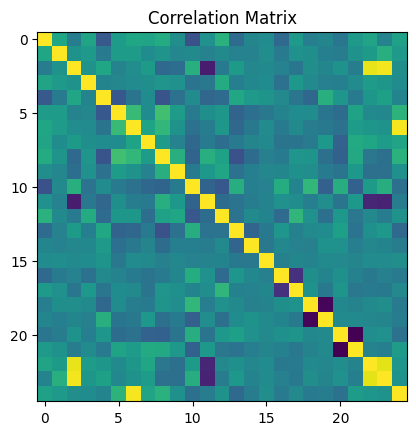

In [10]:
plt.figure()
plt.imshow(df.corr())
plt.title("Correlation Matrix")
plt.show()

In [11]:
X = df.drop("num", axis=1)
y = df["num"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=15,        # only 15 random combinations
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced'}


In [14]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

               Feature  Importance
5                exang    0.097038
4               thalch    0.094141
21            age_chol    0.093373
22             bp_chol    0.084440
23           stress_hr    0.078045
6              oldpeak    0.076268
0                  age    0.072978
2                 chol    0.070693
12  cp_atypical angina    0.053014
1             trestbps    0.043721


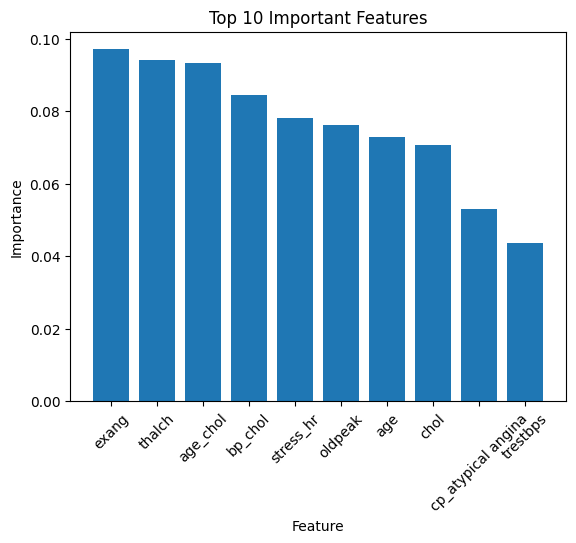

In [15]:
plt.figure()
plt.bar(
    importance_df["Feature"].head(10),
    importance_df["Importance"].head(10)
)
plt.xticks(rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Top 10 Important Features")
plt.show()

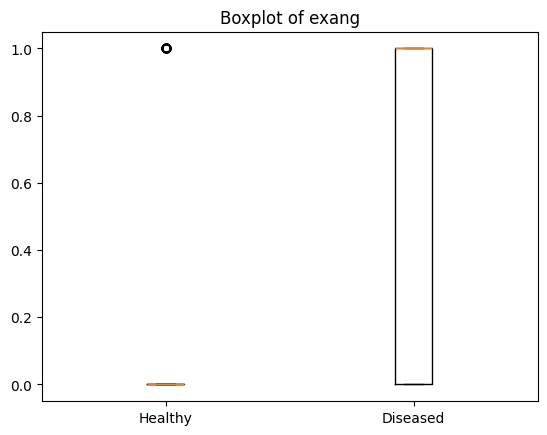

In [52]:
top_feature = importance_df["Feature"].iloc[0]

healthy = df[df["num"] == 0][top_feature].astype(int)
diseased = df[df["num"] == 1][top_feature].astype(int)

plt.figure()
plt.boxplot([healthy, diseased])
plt.xticks([1, 2], ["Healthy", "Diseased"])
plt.title(f"Boxplot of {top_feature}")
plt.show()

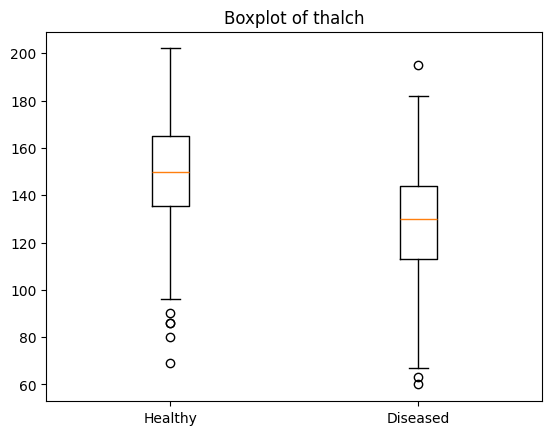

In [53]:
# Get only continuous features (exclude dummy columns)
continuous_features = [
    col for col in X.columns
    if df[col].dtype != "uint8" and df[col].dtype != "bool"
]

# Pick most important continuous feature
for feature in importance_df["Feature"]:
    if feature in continuous_features:
        top_feature = feature
        break

healthy = df[df["num"] == 0][top_feature]
diseased = df[df["num"] == 1][top_feature]

plt.figure()
plt.boxplot([healthy, diseased])
plt.xticks([1, 2], ["Healthy", "Diseased"])
plt.title(f"Boxplot of {top_feature}")
plt.show()

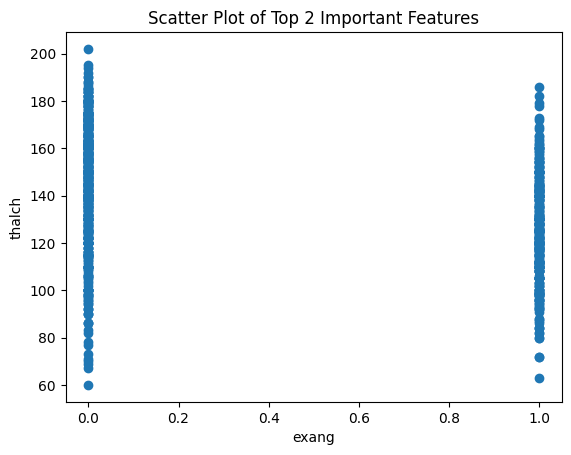

In [54]:
feature1 = importance_df["Feature"].iloc[0]
feature2 = importance_df["Feature"].iloc[1]

plt.figure()
plt.scatter(df[feature1], df[feature2])
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title("Scatter Plot of Top 2 Important Features")
plt.show()

In [55]:
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.8586956521739131

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.82      0.84        82
           1       0.86      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184


Confusion Matrix:

[[67 15]
 [11 91]]


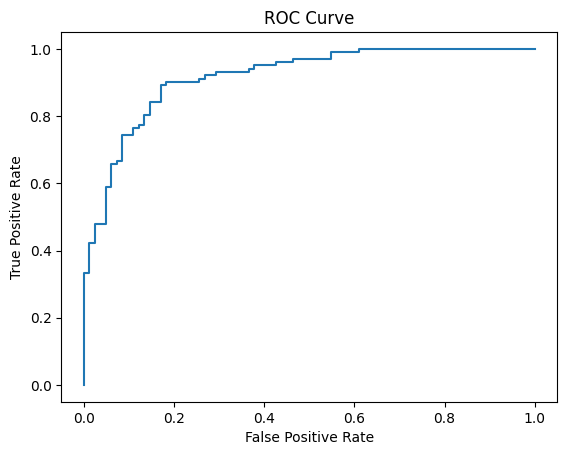

AUC Score: 0.9166666666666666


In [56]:
y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc)

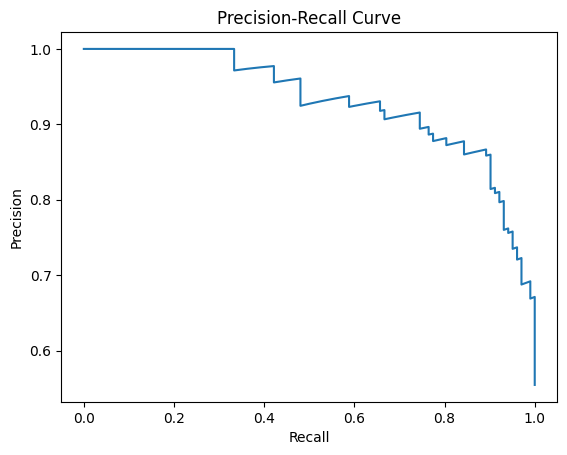

In [57]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [58]:
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5)

print("Cross Validation Accuracy:", cv_scores.mean())

Cross Validation Accuracy: 0.7608695652173912
